In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)


2026-02-13 11:49:03.097674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770983343.489869     101 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770983343.601562     101 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770983344.558405     101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770983344.558437     101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770983344.558439     101 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [ ]:
# DATASET PATH
BASE_PATH = "/kaggle/input/datasets/prathvichavan/skin-diesease-dataset-per-class-2-5k-images/BALANCED_CLASSES"

# OUTPUT PATH
WORK_DIR = "/kaggle/working"

# IMAGE + TRAINING PARAMS
IMG_SIZE = 380
BATCH_SIZE = 16
EPOCHS_HEAD = 5        # warm-up
EPOCHS_FINE = 20       # fine-tuning
RANDOM_STATE = 42


In [ ]:
CLASS_MAPPING = {
    "atopic_dermatitis":        ("benign", "inflammatory"),
    "eczema":                   ("benign", "inflammatory"),
    "psoriasis_lichen_planus":  ("benign", "inflammatory"),

    "tinea_ringworm":           ("benign", "infectious"),
    "warts_viral":              ("benign", "infectious"),

    "melanocytic_nevi":         ("benign", "benign_tumors"),
    "benign_keratosis":         ("benign", "benign_tumors"),
    "seborrheic_keratosis":     ("benign", "benign_tumors"),

    "melanoma":                 ("malignant", "melanoma"),
    "basal_cell_carcinoma":     ("malignant", "bcc")
}


In [ ]:
records = []

for folder in os.listdir(BASE_PATH):
    folder_path = os.path.join(BASE_PATH, folder)
    if folder not in CLASS_MAPPING:
        continue

    level1, level2 = CLASS_MAPPING[folder]

    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "image_path": os.path.join(folder_path, img),
                "level1": level1,
                "level2": level2
            })

df = pd.DataFrame(records)
csv_path = os.path.join(WORK_DIR, "labels.csv")
df.to_csv(csv_path, index=False)

print("Total images:", len(df))
print(df["level1"].value_counts())
print(df["level2"].value_counts())


Total images: 25000
level1
benign       20000
malignant     5000
Name: count, dtype: int64
level2
inflammatory     7500
benign_tumors    7500
infectious       5000
bcc              2500
melanoma         2500
Name: count, dtype: int64


In [ ]:
df_lvl1 = df[["image_path", "level1"]].copy()
df_lvl1["label"] = df_lvl1["level1"].map({"benign": 0, "malignant": 1})

train_df, val_df = train_test_split(
    df_lvl1,
    test_size=0.2,
    stratify=df_lvl1["label"],
    random_state=RANDOM_STATE
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)


Train: (20000, 3)
Val: (5000, 3)


In [ ]:
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.625), 1: np.float64(2.5)}


In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)   # ✅ EfficientNet requirement
    return img, label


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"], train_df["label"])
)
train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1024)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"], val_df["label"])
)
val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


I0000 00:00:1770983363.942549     101 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770983363.948901     101 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # 🔒 warm-up phase

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR")
    ]
)


In [ ]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3),
    ModelCheckpoint(
        "/kaggle/working/level1_best.keras",
        monitor="val_auc_pr",
        save_best_only=True,
        mode="max"
    )
]


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint(
        "/kaggle/working/level1_b4_best.h5",
        monitor="val_auc",
        save_best_only=True,
        mode="max"
    )
]


In [ ]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/5


I0000 00:00:1770983390.741166     162 service.cc:152] XLA service 0x7862a00029a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770983390.741205     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770983390.741210     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770983395.165776     162 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-13 11:50:06.574448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:50:06.720590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:50:06.984102: E external/local_xl

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.7229 - auc: 0.8327 - loss: 0.5061 - recall: 0.8553

2026-02-13 11:54:02.786447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:54:02.924325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:54:03.162976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:54:03.301732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 11:54:03.575388: E external/local_xla/xla/stream_

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 285s 183ms/step - acc: 0.7229 - auc: 0.8328 - loss: 0.5061 - recall: 0.8553 - val_acc: 0.8090 - val_auc: 0.9265 - val_loss: 0.3924 - val_recall: 0.9780 - learning_rate: 1.0000e-04
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.8226 - auc: 0.9268 - loss: 0.3283 - recall: 0.9521

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 207s 164ms/step - acc: 0.8226 - auc: 0.9268 - loss: 0.3283 - recall: 0.9521 - val_acc: 0.8296 - val_auc: 0.9435 - val_loss: 0.3464 - val_recall: 0.9720 - learning_rate: 1.0000e-04
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.8435 - auc: 0.9420 - loss: 0.2928 - recall: 0.9532

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 208s 164ms/step - acc: 0.8435 - auc: 0.9420 - loss: 0.2928 - recall: 0.9533 - val_acc: 0.8418 - val_auc: 0.9522 - val_loss: 0.3180 - val_recall: 0.9660 - learning_rate: 1.0000e-04
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.8551 - auc: 0.9485 - loss: 0.2760 - recall: 0.9557

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 208s 165ms/step - acc: 0.8551 - auc: 0.9485 - loss: 0.2760 - recall: 0.9557 - val_acc: 0.8456 - val_auc: 0.9571 - val_loss: 0.3111 - val_recall: 0.9710 - learning_rate: 1.0000e-04
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.8608 - auc: 0.9540 - loss: 0.2617 - recall: 0.9524

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 209s 165ms/step - acc: 0.8608 - auc: 0.9540 - loss: 0.2617 - recall: 0.9524 - val_acc: 0.8578 - val_auc: 0.9606 - val_loss: 0.2852 - val_recall: 0.9620 - learning_rate: 1.0000e-04


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR")
    ]
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/15


2026-02-13 12:08:40.219610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 12:08:40.373346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 12:08:40.881778: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 12:08:41.022271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 12:08:41.341604: E external/local_xla/xla/stream_

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - auc_pr: 0.7788 - loss: 0.3320 - recall: 0.9462

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 307s 203ms/step - auc_pr: 0.7789 - loss: 0.3320 - recall: 0.9462 - val_auc_pr: 0.8830 - val_loss: 0.2719 - val_recall: 0.9650 - learning_rate: 1.0000e-05
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - auc_pr: 0.8845 - loss: 0.2307 - recall: 0.9451

...

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 184ms/step - auc_pr: 0.9745 - loss: 0.1007 - recall: 0.9710 - val_auc_pr: 0.9679 - val_loss: 0.1127 - val_recall: 0.9660 - learning_rate: 1.0000e-05
Epoch 12/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - auc_pr: 0.9813 - loss: 0.0879 - recall: 0.9793

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 184ms/step - auc_pr: 0.9813 - loss: 0.0879 - recall: 0.9793 - val_auc_pr: 0.9675 - val_loss: 0.1064 - val_recall: 0.9590 - learning_rate: 1.0000e-05
Epoch 13/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - auc_pr: 0.9806 - loss: 0.0859 - recall: 0.9812

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 233s 184ms/step - auc_pr: 0.9806 - loss: 0.0859 - recall: 0.9812 - val_auc_pr: 0.9708 - val_loss: 0.1006 - val_recall: 0.9580 - learning_rate: 1.0000e-05
Epoch 14/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - auc_pr: 0.9826 - loss: 0.0808 - recall: 0.9816

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 231s 183ms/step - auc_pr: 0.9826 - loss: 0.0808 - recall: 0.9816 - val_auc_pr: 0.9716 - val_loss: 0.1003 - val_recall: 0.9610 - learning_rate: 1.0000e-05
Epoch 15/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - auc_pr: 0.9856 - loss: 0.0771 - recall: 0.9819

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 231s 183ms/step - auc_pr: 0.9856 - loss: 0.0771 - recall: 0.9819 - val_auc_pr: 0.9705 - val_loss: 0.0961 - val_recall: 0.9530 - learning_rate: 1.0000e-05


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/kaggle/working/level1_b4_best.h5")
print("✅ Best trained model loaded")



✅ Best trained model loaded


In [ ]:
y_true = val_df["label"].values
y_prob = best_model.predict(val_ds).ravel()

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob >= t).astype(int)
    recall = tf.keras.metrics.Recall()(y_true, y_pred).numpy()
    print(f"Threshold {t}: Recall = {recall:.3f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 172ms/step
Threshold 0.2: Recall = 0.978
Threshold 0.3: Recall = 0.972
Threshold 0.4: Recall = 0.963
Threshold 0.5: Recall = 0.953


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

THRESHOLD = 0.3   # 👈 lock this

y_pred = (y_prob >= THRESHOLD).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    target_names=["Benign", "Malignant"]
))


[[3806  194]
 [  28  972]]
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      4000
   Malignant       0.83      0.97      0.90      1000

    accuracy                           0.96      5000
   macro avg       0.91      0.96      0.93      5000
weighted avg       0.96      0.96      0.96      5000



In [ ]:
# Final threshold (LOCKED)
LEVEL1_THRESHOLD = 0.3

# Save final model (best one already loaded)
best_model.save("/kaggle/working/level1_final_locked.keras")

# Save threshold for later inference
import json
with open("/kaggle/working/level1_config.json", "w") as f:
    json.dump({"threshold": LEVEL1_THRESHOLD}, f)

print("✅ Level-1 model & threshold locked")


✅ Level-1 model & threshold locked


In [ ]:
import numpy as np

def level1_predict(model, image_batch, threshold=0.3):
    """
    image_batch: preprocessed images (same preprocessing as training)
    return: 0 = benign, 1 = malignant
    """
    probs = model.predict(image_batch).ravel()
    preds = (probs >= threshold).astype(int)
    return preds, probs


## Level-1 Classification (Benign vs Malignant)

- Model: EfficientNet-B4
- Threshold: 0.3
- Validation Recall (Malignant): 97%
- False Negative Rate: 2.6%

This model acts as a gatekeeper in the hierarchical pipeline.
Only images predicted as benign or malignant are forwarded
to their respective Level-2 classifiers.


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
CSV_PATH = "/kaggle/working/labels.csv"

df = pd.read_csv(CSV_PATH)

# Keep only BENIGN samples
benign_df = df[df["level1"] == "benign"].copy()

print("Total benign images:", len(benign_df))
print(benign_df["level2"].value_counts())


Total benign images: 20000
level2
inflammatory     7500
benign_tumors    7500
infectious       5000
Name: count, dtype: int64


In [ ]:
LABEL_MAP = {
    "inflammatory": 0,
    "infectious": 1,
    "benign_tumors": 2
}

benign_df["label"] = benign_df["level2"].map(LABEL_MAP)


In [ ]:
train_df, val_df = train_test_split(
    benign_df,
    test_size=0.2,
    stratify=benign_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)


Train: (16000, 4)
Val: (4000, 4)


In [ ]:
IMG_SIZE = 380
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"], train_df["label"])
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"], val_df["label"])
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # warm-up first

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3),
    ModelCheckpoint(
        "/kaggle/working/level2_benign_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 221s 179ms/step - accuracy: 0.4985 - loss: 0.9880 - val_accuracy: 0.6500 - val_loss: 0.7623 - learning_rate: 3.0000e-05
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 167s 165ms/step - accuracy: 0.6364 - loss: 0.7802 - val_accuracy: 0.6712 - val_loss: 0.7089 - learning_rate: 3.0000e-05
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 167s 165ms/step - accuracy: 0.6503 - loss: 0.7368 - val_accuracy: 0.6812 - val_loss: 0.6847 - learning_rate: 3.0000e-05
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 168s 165ms/step - accuracy: 0.6583 - loss: 0.7132 - val_accuracy: 0.6905 - val_loss: 0.6687 - learning_rate: 3.0000e-05
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 167s 165ms/step - accuracy: 0.6714 - loss: 0.6943 - val_accuracy: 0.6985 - val_loss: 0.6574 - learning_rate: 3.0000e-05
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 167s 165ms/step - accuracy: 0.6854 - loss: 0.6756 - val_accuracy: 0.7032 - val_loss: 0.6484 - learning_rate: 3.0000e-05
Epoch 7/10
1000/1000 ━━━━━━━

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 247s 197ms/step - accuracy: 0.6749 - loss: 0.7132 - val_accuracy: 0.7255 - val_loss: 0.6064 - learning_rate: 1.0000e-05
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 184ms/step - accuracy: 0.7145 - loss: 0.6306 - val_accuracy: 0.7437 - val_loss: 0.5730 - learning_rate: 1.0000e-05
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 183ms/step - accuracy: 0.7314 - loss: 0.6009 - val_accuracy: 0.7570 - val_loss: 0.5493 - learning_rate: 1.0000e-05
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 183ms/step - accuracy: 0.7552 - loss: 0.5650 - val_accuracy: 0.7663 - val_loss: 0.5312 - learning_rate: 1.0000e-05
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 184ms/step - accuracy: 0.7614 - loss: 0.5414 - val_accuracy: 0.7732 - val_loss: 0.5157 - learning_rate: 1.0000e-05
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 184ms/step - accuracy: 0.7715 - loss: 0.5234 - val_accuracy: 0.7800 - val_loss: 0.5012 - learning_rate: 1.0000e-05
Epoch 7/15
1000/1000 ━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

best_benign_model = load_model("/kaggle/working/level2_benign_best.keras")
print("✅ Best Level-2 Benign model loaded")


✅ Best Level-2 Benign model loaded


In [ ]:
best_benign_model.save("/kaggle/working/level2_benign_final.keras")
print("✅ Level-2 Benign model LOCKED")


✅ Level-2 Benign model LOCKED


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = val_df["label"].values
y_pred = np.argmax(best_benign_model.predict(val_ds), axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    target_names=["Inflammatory", "Infectious", "Benign_Tumors"]
))


250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step
[[1260  197   43]
 [ 280  667   53]
 [  57   69 1374]]
               precision    recall  f1-score   support

 Inflammatory       0.79      0.84      0.81      1500
   Infectious       0.71      0.67      0.69      1000
Benign_Tumors       0.93      0.92      0.93      1500

     accuracy                           0.83      4000
    macro avg       0.81      0.81      0.81      4000
 weighted avg       0.83      0.83      0.82      4000



In [ ]:
LABEL_MAP_BENIGN = {
    0: "Inflammatory",
    1: "Infectious",
    2: "Benign_Tumors"
}


In [ ]:
import json

with open("/kaggle/working/level2_benign_labels.json", "w") as f:
    json.dump(LABEL_MAP_BENIGN, f)

print("✅ Level-2 Benign label map saved")


✅ Level-2 Benign label map saved


In [ ]:
import numpy as np

cm_benign = confusion_matrix(y_true, y_pred)
np.save("/kaggle/working/level2_benign_confusion.npy", cm_benign)


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true, y_pred,
    target_names=["Inflammatory","Infectious","Benign_Tumors"],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("/kaggle/working/level2_benign_report.csv")

print("✅ Level-2 Benign report saved")


✅ Level-2 Benign report saved


Level-2 Benign Model
Architecture : EfficientNet-B4
Classes       : Inflammatory | Infectious | Benign Tumors
Val Accuracy  : 0.83
Macro F1      : 0.81


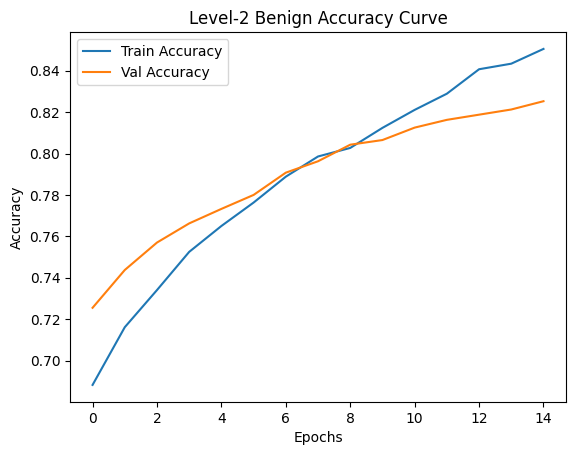

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Level-2 Benign Accuracy Curve')
plt.legend()
plt.show()


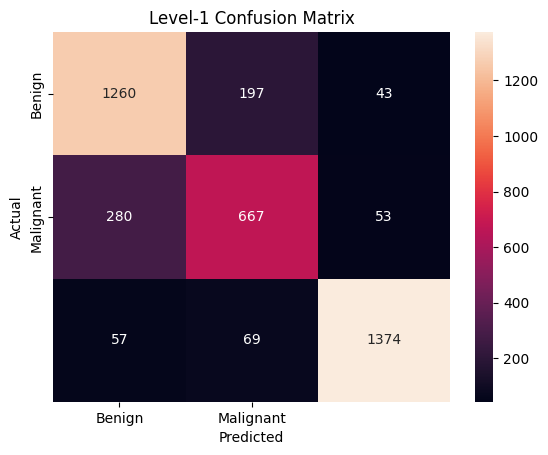

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Level-1 Confusion Matrix')
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
CSV_PATH = "/kaggle/working/labels.csv"

df = pd.read_csv(CSV_PATH)

# Keep only MALIGNANT samples
malignant_df = df[df["level1"] == "malignant"].copy()

print("Total malignant images:", len(malignant_df))
print(malignant_df["level2"].value_counts())


Total malignant images: 5000
level2
bcc         2500
melanoma    2500
Name: count, dtype: int64


In [ ]:
LABEL_MAP_MALIGNANT = {
    "bcc": 0,
    "melanoma": 1
}

malignant_df["label"] = malignant_df["level2"].map(LABEL_MAP_MALIGNANT)


In [ ]:
train_df, val_df = train_test_split(
    malignant_df,
    test_size=0.2,
    stratify=malignant_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)


Train: (4000, 4)
Val: (1000, 4)


In [ ]:
IMG_SIZE = 380
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"], train_df["label"])
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(512).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"], val_df["label"])
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # warm-up

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [ ]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3),
    ModelCheckpoint(
        "/kaggle/working/level2_malignant_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max"
    )
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 261ms/step - auc: 0.4083 - loss: 0.7583 - recall: 0.3787 - val_auc: 0.8355 - val_loss: 0.6235 - val_recall: 0.8200 - learning_rate: 3.0000e-05
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 175ms/step - auc: 0.7850 - loss: 0.6027 - recall: 0.7492 - val_auc: 0.9659 - val_loss: 0.5140 - val_recall: 0.9520 - learning_rate: 3.0000e-05
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - auc: 0.9190 - loss: 0.5058 - recall: 0.8946 - val_auc: 0.9830 - val_loss: 0.4406 - val_recall: 0.9660 - learning_rate: 3.0000e-05
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - auc: 0.9536 - loss: 0.4402 - recall: 0.9382 - val_auc: 0.9875 - val_loss: 0.3882 - val_recall: 0.9660 - learning_rate: 3.0000e-05
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 177ms/step - auc: 0.9618 - loss: 0.3955 - recall: 0.9426 - val_auc: 0.9897 - val_loss: 0.3488 - val_recall: 0.9680 - learning_rate: 3.0000e-05
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - auc: 0.

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 121s 283ms/step - auc: 0.9727 - loss: 0.3363 - recall: 0.9202 - val_auc: 0.9976 - val_loss: 0.1653 - val_recall: 0.9700 - learning_rate: 1.0000e-05
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 195ms/step - auc: 0.9919 - loss: 0.1821 - recall: 0.9496 - val_auc: 0.9990 - val_loss: 0.1078 - val_recall: 0.9780 - learning_rate: 1.0000e-05
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 192ms/step - auc: 0.9950 - loss: 0.1302 - recall: 0.9541 - val_auc: 0.9995 - val_loss: 0.0777 - val_recall: 0.9880 - learning_rate: 1.0000e-05
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 193ms/step - auc: 0.9960 - loss: 0.1018 - recall: 0.9671 - val_auc: 0.9997 - val_loss: 0.0606 - val_recall: 0.9900 - learning_rate: 1.0000e-05
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 192ms/step - auc: 0.9964 - loss: 0.0891 - recall: 0.9713 - val_auc: 0.9998 - val_loss: 0.0496 - val_recall: 0.9920 - learning_rate: 1.0000e-05
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 193ms/step - auc: 0.

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model

best_malignant_model = load_model("/kaggle/working/level2_malignant_best.keras")

y_true = val_df["label"].values
y_prob = best_malignant_model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    target_names=["BCC", "Melanoma"]
))


63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step
[[495   5]
 [  2 498]]
              precision    recall  f1-score   support

         BCC       1.00      0.99      0.99       500
    Melanoma       0.99      1.00      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [ ]:
best_malignant_model.save("/kaggle/working/level2_malignant_final.keras")
print("✅ Level-2 Malignant model saved")


✅ Level-2 Malignant model saved


In [ ]:
import json

LABEL_MAP_MALIGNANT_INV = {
    0: "BCC",
    1: "Melanoma"
}

with open("/kaggle/working/level2_malignant_labels.json", "w") as f:
    json.dump(LABEL_MAP_MALIGNANT_INV, f)

print("✅ Level-2 Malignant label map saved")


✅ Level-2 Malignant label map saved


In [ ]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input


In [ ]:
# Load models
level1_model = load_model("/kaggle/working/level1_final_locked.keras")
level2_benign_model = load_model("/kaggle/working/level2_benign_final.keras")
level2_malignant_model = load_model("/kaggle/working/level2_malignant_final.keras")

# Load label maps
with open("/kaggle/working/level2_benign_labels.json") as f:
    BENIGN_LABELS = json.load(f)

with open("/kaggle/working/level2_malignant_labels.json") as f:
    MALIGNANT_LABELS = json.load(f)

LEVEL1_THRESHOLD = 0.3

print("✅ All models & configs loaded")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ All models & configs loaded


In [ ]:
IMG_SIZE = 380

def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)
    return img


In [ ]:
def level1_predict(image_tensor):
    prob = level1_model.predict(image_tensor)[0][0]
    pred = 1 if prob >= LEVEL1_THRESHOLD else 0
    return pred, prob


In [ ]:
def level2_benign_predict(image_tensor):
    probs = level2_benign_model.predict(image_tensor)[0]
    class_id = np.argmax(probs)
    class_name = BENIGN_LABELS[str(class_id)]
    confidence = probs[class_id]
    return class_name, confidence


In [ ]:
def level2_malignant_predict(image_tensor):
    prob = level2_malignant_model.predict(image_tensor)[0][0]
    class_id = 1 if prob >= 0.5 else 0
    class_name = MALIGNANT_LABELS[str(class_id)]
    confidence = prob if class_id == 1 else (1 - prob)
    return class_name, confidence


In [ ]:
def hierarchical_predict(image_path):
    image_tensor = preprocess_image(image_path)

    # Level-1
    level1_class, level1_prob = level1_predict(image_tensor)

    if level1_class == 0:
        # Benign path
        level2_class, level2_conf = level2_benign_predict(image_tensor)
        return {
            "Level-1": "Benign",
            "Level-1 Confidence": float(1 - level1_prob),
            "Final Diagnosis": level2_class,
            "Final Confidence": float(level2_conf)
        }
    else:
        # Malignant path
        level2_class, level2_conf = level2_malignant_predict(image_tensor)
        return {
            "Level-1": "Malignant",
            "Level-1 Confidence": float(level1_prob),
            "Final Diagnosis": level2_class,
            "Final Confidence": float(level2_conf)
        }


In [ ]:
test_image = "/kaggle/input/datasets/prathvichavan/skin-diesease-dataset-per-class-2-5k-images/BALANCED_CLASSES/melanoma/ISIC_6653780.jpg"

result = hierarchical_predict(test_image)

for k, v in result.items():
    print(f"{k}: {v}")


2026-02-13 14:52:59.251596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 14:52:59.387388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 14:52:59.712211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 14:52:59.857490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 14:53:00.591525: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Level-1: Malignant
Level-1 Confidence: 0.9937614798545837
Final Diagnosis: Melanoma
Final Confidence: 0.9707032442092896


In [ ]:
import os

def batch_predict(image_folder):
    results = []
    for img in os.listdir(image_folder):
        if img.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(image_folder, img)
            pred = hierarchical_predict(path)
            pred["image"] = img
            results.append(pred)
    return results


In [1]:
import tensorflow as tf
import keras
import h5py
import numpy as np

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("h5py:", h5py.__version__)
print("NumPy:", np.__version__)


TensorFlow: 2.19.0
Keras: 3.10.0
h5py: 3.15.1
NumPy: 2.0.2


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [3]:
model = tf.keras.models.load_model(
    "level1_final_locked.keras",
    compile=False
)

print("✅ Keras-3 model loaded successfully")


✅ Keras-3 model loaded successfully


In [4]:
IMG_SIZE = 380

def preprocess_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    img = tf.expand_dims(img, axis=0)
    return img


In [6]:
for layer in reversed(model.layers):
    try:
        shape = layer.output.shape
        if len(shape) == 4:
            print("Last Conv Layer:", layer.name)
            break
    except:
        continue


Last Conv Layer: top_activation


In [7]:
LAST_CONV_LAYER = "top_conv"   # 👈 jo print hua wahi daalo

def make_gradcam_heatmap(img_tensor, model):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(LAST_CONV_LAYER).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]  # malignant probability

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)
    return heatmap.numpy()


In [8]:
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = img * (1 - alpha) + heatmap * alpha
    return overlay.astype(np.uint8)


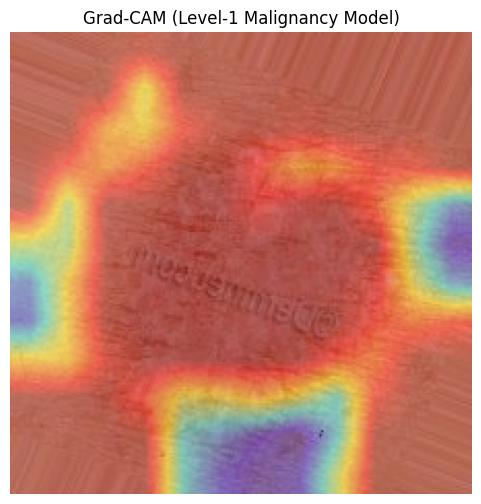

In [9]:
test_image = "/content/psoriasis_lichen_planus_aug_27.jpg"   # 👈 apna image path

img_tensor = preprocess_image(test_image)
heatmap = make_gradcam_heatmap(img_tensor, model)
overlay = overlay_gradcam(test_image, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM (Level-1 Malignancy Model)")
plt.show()


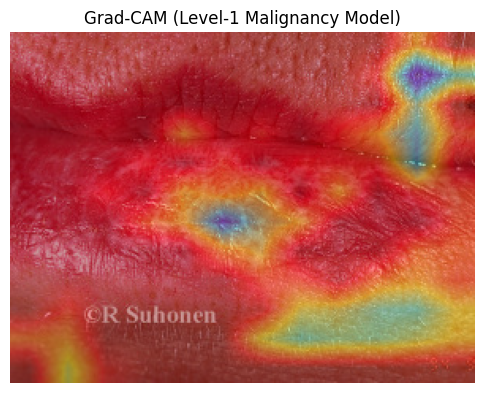

In [12]:
test_image = "/content/psoriasis_lichen_planus_0_27.jpg" # 👈 apna image path

img_tensor = preprocess_image(test_image)
heatmap = make_gradcam_heatmap(img_tensor, model)
overlay = overlay_gradcam(test_image, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM (Level-1 Malignancy Model)")
plt.show()


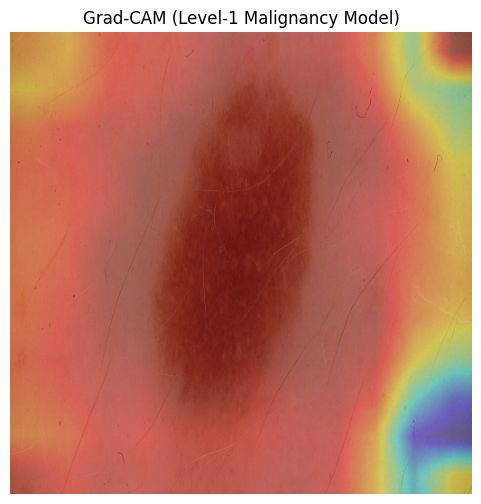

In [13]:
test_image = "/content/melanoma_ISIC_6653456.jpg"   # 👈 apna image path

img_tensor = preprocess_image(test_image)
heatmap = make_gradcam_heatmap(img_tensor, model)
overlay = overlay_gradcam(test_image, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM (Level-1 Malignancy Model)")
plt.show()


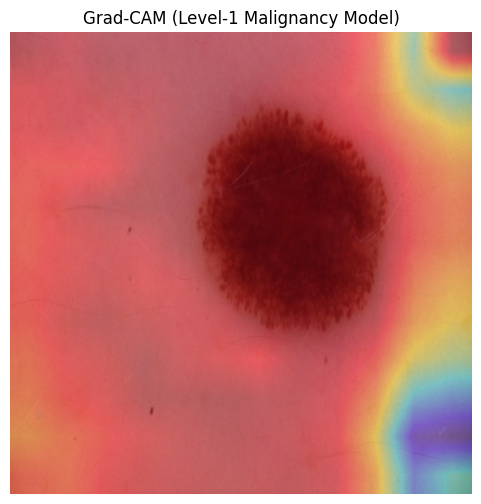

In [16]:
test_image = "/content/melanoma_ISIC_6661910.jpg"   # 👈 apna image path

img_tensor = preprocess_image(test_image)
heatmap = make_gradcam_heatmap(img_tensor, model)
overlay = overlay_gradcam(test_image, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM (Level-1 Malignancy Model)")
plt.show()


In [17]:
def level1_predict(img_tensor, model, threshold=0.3):
    prob = model.predict(img_tensor, verbose=0)[0][0]
    label = "Malignant" if prob >= threshold else "Benign"
    return label, float(prob)


In [18]:
import csv

def save_prediction(image_name, label, prob, file="level1_results.csv"):
    with open(file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([image_name, label, prob])


In [19]:
from sklearn.metrics import recall_score


In [1]:
import os
import shutil
import pandas as pd
import numpy as np


C:\Users\Acer\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Acer\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [7]:
IMG_DIR_1 = r"C:\Users\Acer\Desktop\skin disease project\test\HAM10000_images_part_1"
IMG_DIR_2 = r"C:\Users\Acer\Desktop\skin disease project\test\HAM10000_images_part_2"

CSV_PATH = r"C:\Users\Acer\Desktop\skin disease project\test\HAM10000_metadata.csv"
OUT_DIR = r"C:\Users\Acer\Desktop\skin disease project\test\external_test"


In [9]:
os.makedirs(os.path.join(OUT_DIR, "melanoma"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "benign"), exist_ok=True)

print("✅ Output folders ready")


✅ Output folders ready


In [11]:
df = pd.read_csv(CSV_PATH)

print(df["dx"].value_counts())


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [13]:
mel_df = df[df["dx"] == "mel"]
ben_df = df[df["dx"] != "mel"]


In [15]:
mel_sample = mel_df.sample(n=300, random_state=42)
ben_sample = ben_df.sample(n=300, random_state=42)

print(len(mel_sample), len(ben_sample))


300 300


In [17]:
def find_and_copy(img_id, target_folder):
    filename = img_id + ".jpg"

    src1 = os.path.join(IMG_DIR_1, filename)
    src2 = os.path.join(IMG_DIR_2, filename)

    if os.path.exists(src1):
        shutil.copy(src1, target_folder)
    elif os.path.exists(src2):
        shutil.copy(src2, target_folder)
    else:
        print("❌ Image not found:", filename)

# Copy melanoma
for img_id in mel_sample["image_id"]:
    find_and_copy(img_id, os.path.join(OUT_DIR, "melanoma"))

# Copy benign
for img_id in ben_sample["image_id"]:
    find_and_copy(img_id, os.path.join(OUT_DIR, "benign"))

print("✅ Images copied from both folders")


✅ Images copied from both folders


In [19]:
print("Melanoma images:", len(os.listdir(os.path.join(OUT_DIR, "melanoma"))))
print("Benign images:", len(os.listdir(os.path.join(OUT_DIR, "benign"))))


Melanoma images: 300
Benign images: 300


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
import tensorflow as tf
import os

MODEL_DIR = r"C:\Users\Acer\Desktop\skin disease project\hf_model"

level1_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "level1_final_locked.keras"),
    compile=False
)

benign_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "level2_benign_final.keras"),
    compile=False
)

mal_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "level2_malignant_final.keras"),
    compile=False
)

print("✅ All models loaded successfully")


OSError: Unable to synchronously open file (file signature not found)

In [10]:
import os
os.getcwd()


'C:\\Users\\Acer\\Desktop\\skin disease project'